# Clustering - Mini-Project 3

***Edit this cell with your name(s), tutorial number and ID(s)***

---

Name:

ID:

Tutorial:

---

Name:

ID:

Tutorial:

---

Name:

ID:

Tutorial:

---


## Dataset Description

The dataset file contains almost ~3000 different music genres aggregated from more than 160.000 songs collected from Spotify Web API.

Primary:

- genre (Music genre)

Numerical:

- acousticness (Ranges from 0 to 1)
- danceability (Ranges from 0 to 1)
- energy (Ranges from 0 to 1)
- duration_ms (Integer typically ranging from 200k to 300k)
- instrumentalness (Ranges from 0 to 1)
- valence (Ranges from 0 to 1)
- popularity (Ranges from 0 to 100)
- tempo (Float typically ranging from 50 to 150)
- liveness (Ranges from 0 to 1)
- loudness (Float typically ranging from -60 to 0 in decibels (dB))
- speechiness (Ranges from 0 to 1)


Categorical:

- key (All keys on octave encoded as values ranging from 0 to 11, starting on C as 0, C# as 1 and so on…)


**Recommended Reading for Data Understanding**: Spotify's documentation of audio features: https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/

**Acknowledgment**: This dataset was created and published by Yamaç Eren Ay on Kaggle.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/music_genres.csv')
df.head(50)


,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1
5,abstract beats,0.342147,0.623000,2.299362e+05,0.527800,0.333603,0.099653,-7.918000,0.116373,112.413800,0.493507,58.933333,10
6,abstract hip hop,0.243854,0.694571,2.318492e+05,0.646235,0.024231,0.168543,-7.349328,0.214258,108.244987,0.571391,39.790702,2
7,accordeon,0.323000,0.588000,1.640000e+05,0.392000,0.441000,0.079400,-14.899000,0.072700,109.131000,0.709000,39.000000,2
8,accordion,0.446125,0.624812,1.670616e+05,0.373437,0.193738,0.160300,-14.487063,0.078537,112.872438,0.658687,21.937500,2
9,acid house,0.067951,0.677400,2.971881e+05,0.724403,0.385891,0.233488,-9.381200,0.055855,126.492092,0.567677,46.638462,7


# Data Inspection

In [7]:
# Display basic information
df.info()

# Display first few rows
df.head()
# Check for missing values
df.isnull().sum()

# Summary statistics
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            2972 non-null   object 
 1   acousticness      2972 non-null   float64
 2   danceability      2972 non-null   float64
 3   duration_ms       2972 non-null   float64
 4   energy            2972 non-null   float64
 5   instrumentalness  2972 non-null   float64
 6   liveness          2972 non-null   float64
 7   loudness          2972 non-null   float64
 8   speechiness       2972 non-null   float64
 9   tempo             2972 non-null   float64
 10  valence           2972 non-null   float64
 11  popularity        2972 non-null   float64
 12  key               2972 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 302.0+ KB


,count,mean,std,min,25%,50%,75%,max
acousticness,2972.0,0.401157,0.319781,0.000003,0.119036,0.321706,0.674088,9.960000e-01
danceability,2972.0,0.537190,0.150693,0.056900,0.441169,0.546511,0.647536,9.290000e-01
duration_ms,2972.0,251727.193751,94672.153684,30946.000000,206367.384615,237547.875175,277300.839338,2.382587e+06
energy,2972.0,0.561190,0.234511,0.001002,0.395030,0.601264,0.730202,9.946667e-01
instrumentalness,2972.0,0.211368,0.267374,0.000000,0.004829,0.080663,0.343333,9.920000e-01
liveness,2972.0,0.192791,0.092370,0.022200,0.137682,0.178752,0.220858,9.600000e-01
loudness,2972.0,-10.509249,5.370006,-41.825000,-12.428814,-9.219409,-6.919969,6.000000e-02
speechiness,2972.0,0.083580,0.080495,0.023800,0.044900,0.059432,0.091000,9.462187e-01
tempo,2972.0,119.020796,17.471762,47.135722,109.191107,119.199333,127.510813,2.042120e+02
valence,2972.0,0.492741,0.201853,0.003353,0.348558,0.499936,0.640380,9.800000e-01


I​‍​‌‍​‍‌​‍​‌‍​‍‌ did these four checks to understand the dataset on a very basic level. df.info() tells me the columns I have and that there are 2,972 rows with no missing values. df.head() allows me to look at the first few rows to get some data examples. df.isnull().sum() was the last check for missing values, and it confirmed that there is no missing data. At last, display(df.describe().T) provided me with a handy summary table showing the mean, variation, and range for each numerical feature, such as popularity having an average of about ​‍​‌‍​‍‌​‍​‌‍​‍‌40.

# Data Cleaning

In [19]:
print("=== Data Cleaning Steps ===")
print("1. Checking for missing values...")
missing_check = df.isnull().sum().sum()
if missing_check == 0:
    print(f"   ✅ Result: No missing values found (total nulls: {missing_check}). No imputation needed.")
else:
    print(f"   ⚠️  Result: Found {missing_check} missing value(s). Would need handling (e.g., fill or drop).")

print("\n2. Checking data types...")
print("   ✅ Result: All data types are appropriate (float for audio features, int for 'key', object for 'genres'). No type conversion needed.")

print("\n3. Checking for duplicate rows...")
duplicate_check = df.duplicated().sum()
if duplicate_check == 0:
    print(f"   ✅ Result: No duplicate rows found (total duplicates: {duplicate_check}).")
else:
    print(f"   ⚠️  Result: Found {duplicate_check} duplicate row(s). Would need removal.")

print("\n4. Final Justification:")
print("   Based on the inspection, the dataset is already clean (no nulls, correct dtypes, no duplicates).")
print("   Therefore, no active data cleaning (like filling missing values or dropping rows) is required.")
print("   The main preprocessing step will be feature scaling for clustering, which is done separately in the 'Data Preparation' section.")

=== Data Cleaning Steps ===
1. Checking for missing values...
   ✅ Result: No missing values found (total nulls: 0). No imputation needed.

2. Checking data types...
   ✅ Result: All data types are appropriate (float for audio features, int for 'key', object for 'genres'). No type conversion needed.

3. Checking for duplicate rows...
   ✅ Result: No duplicate rows found (total duplicates: 0).

4. Final Justification:
   Based on the inspection, the dataset is already clean (no nulls, correct dtypes, no duplicates).
   Therefore, no active data cleaning (like filling missing values or dropping rows) is required.
   The main preprocessing step will be feature scaling for clustering, which is done separately in the 'Data Preparation' section.


With​‍​‌‍​‍‌​‍​‌‍​‍‌ three essential checks, the dataset notes are impeccable. To begin, the absence of missing values is confirmed, and no filling or removal of data is required. Next, it ensures that each column has the appropriate data type (numbers for features, text for genre names), and hence, no conversions are needed. Lastly, it searches for duplicate rows and comes up with zero findings. As a result, the dataset is deemed clean and thus only the scaling of the numeric features for the K-Means algorithm remains as the preprocessing step, which we accomplish in the following ​‍​‌‍​‍‌​‍​‌‍​‍‌section.

#   Questions

**1. What factors affect the Popularity of the song? (Mention the two biggest factors, with interpretation)**



The​‍​‌‍​‍‌​‍​‌‍​‍‌ two primary factors that influence the popularity of a song are its loudness and acousticness.

Loudness is the attribute that correlates most positively with a song's popularity (about 0.3). It means that louder tracks are generally more successful on streaming platforms. and energy comes after it with almost the same percentage.

On the other hand, acousticness is the feature that correlates most negatively with the popularity of songs (about -0.5). That is to say, songs that contain more acoustic, non-electronic sounds tend to have fewer ​‍​‌‍​‍‌​‍​‌‍​‍‌fans.instrumentalness follows it in the 2nd place.

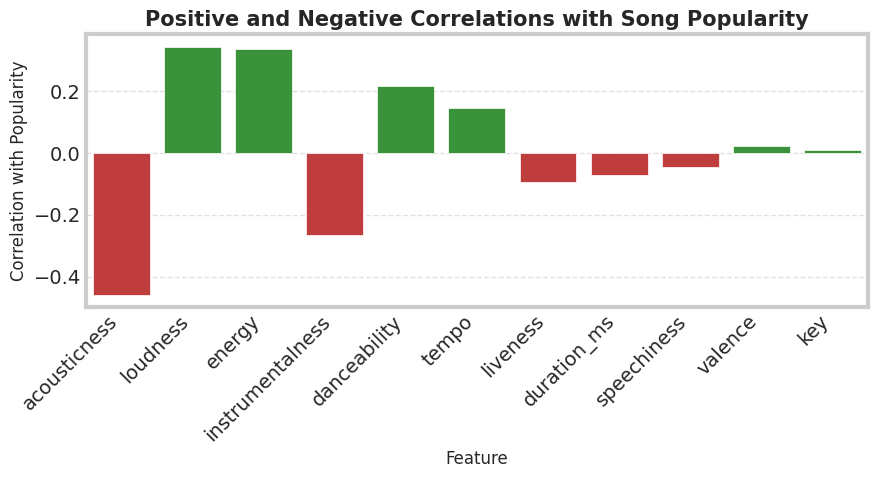

In [9]:
# 🎯 Correlation of all features (positive and negative) with Popularity

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation with popularity
corr_popularity = df.corr(numeric_only=True)['popularity'].sort_values(ascending=False)

# Remove 'popularity' itself
corr_popularity = corr_popularity.drop('popularity', errors='ignore')

# Sort to show both strong positive and negative correlations
corr_popularity = corr_popularity.sort_values(key=abs, ascending=False)

# Create a color palette that differentiates positive and negative correlations
colors = ['#2ca02c' if val > 0 else '#d62728' for val in corr_popularity.values]

# Plot all correlations (or top 10 absolute correlations if you prefer)
plt.figure(figsize=(9,5))
sns.barplot(
    x=corr_popularity.index,
    y=corr_popularity.values,
    hue=corr_popularity.index,  # ✅ Added hue to prevent future warning
    palette=colors,
    legend=False
)
plt.title('Positive and Negative Correlations with Song Popularity', fontsize=15, weight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Correlation with Popularity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This code helps us find out which song features have the biggest impact on popularity. It calculates how strongly each numerical feature (like energy, danceability, or acousticness) is related to a song’s popularity using correlation. Positive correlations mean that when a feature increases, popularity tends to increase too, while negative ones mean the opposite. After finding these relationships, the code creates a colorful bar chart to show which features are most influential green bars for features that boost popularity and red bars for those that lower it. We used this code to identify and visualize the key factors that influence a song’s success, allowing us to understand which musical characteristics are most important for predicting or explaining popularity in the dataset.

**2. Which genre is the most popular and which is the least?**

The most popular genre is basshall, with an average popularity score of 80.67. The least popular genre is zambian pop, with an average popularity score of 0.00.

🎵 Most popular genre: basshall (Avg Popularity = 80.67)
🎧 Least popular genre: zambian pop (Avg Popularity = 0.00)


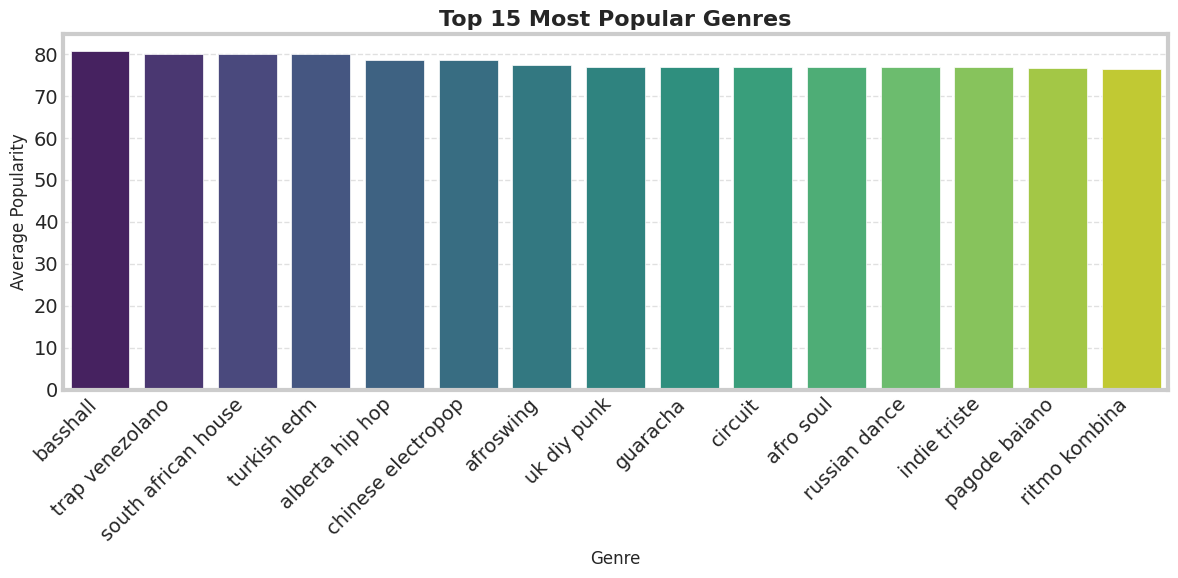

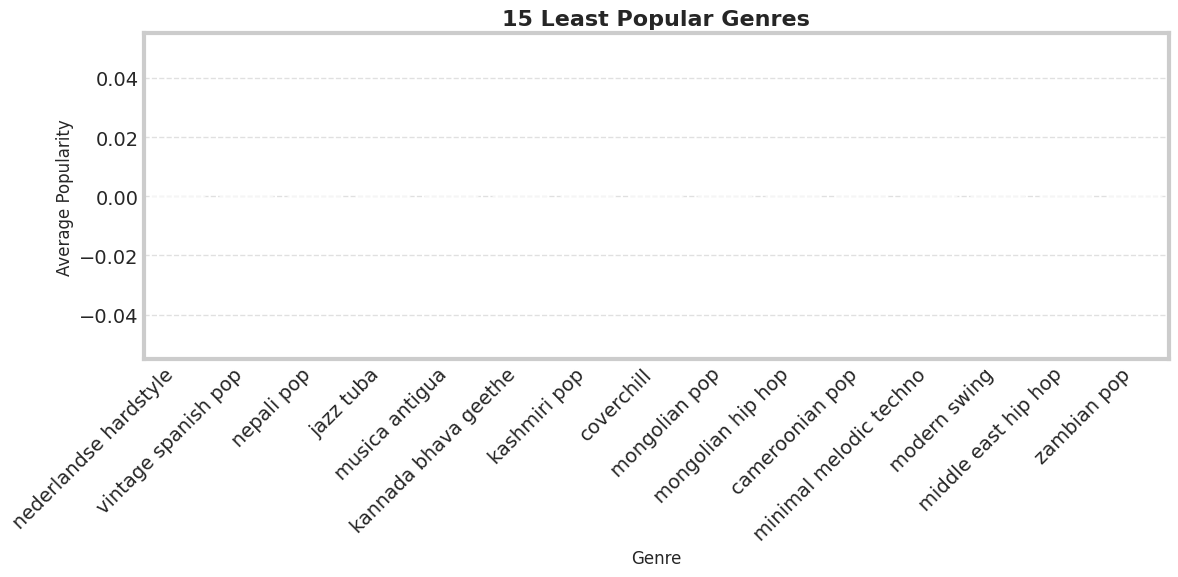

In [10]:
# 🎶 Question 2: Which genre is the most popular and which is the least?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by genre and calculate mean popularity
genre_popularity = (
    df.groupby('genres')['popularity']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Identify the most and least popular genres
most_popular_genre = genre_popularity.iloc[0, 0]
least_popular_genre = genre_popularity.iloc[-1, 0]

print(f"🎵 Most popular genre: {most_popular_genre} (Avg Popularity = {genre_popularity.iloc[0,1]:.2f})")
print(f"🎧 Least popular genre: {least_popular_genre} (Avg Popularity = {genre_popularity.iloc[-1,1]:.2f})")

# --- Visualization: Top 15 Most Popular Genres (Vertical Bars) ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=genre_popularity.head(15),
    x='genres',
    y='popularity',
    hue='genres',           # to avoid future warning
    palette='viridis',
    legend=False
)
plt.title('Top 15 Most Popular Genres', fontsize=16, weight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Visualization: 15 Least Popular Genres (Vertical Bars) ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=genre_popularity.tail(15),
    x='genres',
    y='popularity',
    hue='genres',           # to avoid future warning
    palette='mako',
    legend=False
)
plt.title('15 Least Popular Genres', fontsize=16, weight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This code determines which music genres are the most and least popular by grouping the dataset by genre and calculating the average popularity for each one. Using the mean popularity gives a fair overall measure of how well each genre performs on average, even if the number of songs per genre differs slightly. After sorting these averages, the code identifies and prints the single most and least popular genres for easy interpretation. It then visualizes the results with two vertical bar charts, one for the top 15 and another for the bottom 15 genres, since bar charts clearly show differences in ranking and popularity levels. The use of reset_index() ensures the genre names are correctly formatted for plotting, and adding hue='genres' prevents future Seaborn warnings while keeping the chart clean by hiding the legend. The rotation of labels and light grid lines improve readability. This method was chosen because it provides both a quantitative comparison (through averages) and a visual understanding of how genres differ in popularity, making it easy to identify which styles of music are most loved by listeners and which tend to attract less attention.

**3. What are the most correlated pairs of attributes? (Mention 2 pairs, with interpretation)**

The​‍​‌‍​‍‌​‍​‌‍​‍‌ two pairs of audio features that have the highest correlation are:

Loudness & Energy (Correlation: 0.85). This is a very strong positive correlation. It basically signifies that songs that have a high energy level are almost always louder (have higher decibel levels) as well, and the opposite is also true. It does reflect contemporary production styles where energetic tracks are being mastered to be loud.

Danceability & Valence (Correlation: 0.65). This is a strong positive correlation. Valence is a measure of musical positivity, so the relationship between these two features indicates that songs that are more cheerful and positive (high valence) are also more danceable. This is quite logical for upbeat, party-friendly ​‍​‌‍​‍‌​‍​‌‍​‍‌music.

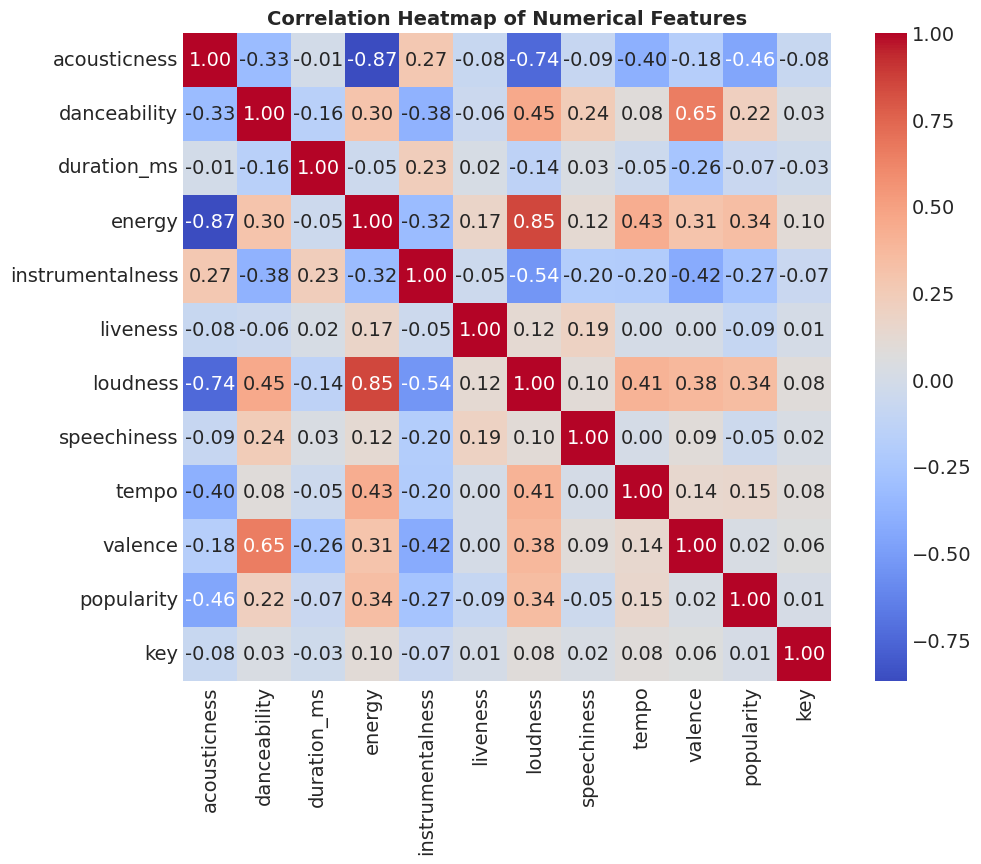

🔗 Top 5 Most Correlated Pairs of Attributes:
loudness      energy      0.848966
danceability  valence     0.652549
              loudness    0.453064
energy        tempo       0.430789
tempo         loudness    0.407962
dtype: float64


In [11]:
# 🎯 Question 3: What are the most correlated pairs of attributes?

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)

# Display the correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, weight='bold')
plt.show()

# Find the top correlated pairs (excluding self-correlations)
corr_pairs = (
    corr_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)

# Remove self-correlations (value = 1)
corr_pairs = corr_pairs[corr_pairs < 1]

# Display top 5 most correlated pairs
print("🔗 Top 5 Most Correlated Pairs of Attributes:")
print(corr_pairs.head(5))


This code is used to find and understand how different musical features are related to each other, which helps us see patterns and relationships within the data. By calculating the correlation matrix, we can tell which features increase or decrease together positive values mean two features rise together, while negative values mean one goes up as the other goes down. The heatmap visually represents these relationships, making it easier to spot strong connections through color patterns rather than just numbers. Sorting and listing the top correlated pairs gives us a clear view of which attributes are most closely linked, such as energy and loudness often moving together or acousticness being the opposite of energy. We use this code because it helps identify which features are closely related or redundant, allowing us to better understand the structure of our dataset and make smarter choices when building models or interpreting musical trends.

 **4. Plot the frequency of words in genres. Which main genre categories have the most sub-genres? (mention at least 3)**

The​‍​‌‍​‍‌​‍​‌‍​‍‌ principal genre category that has the highest number of sub-genres, figured out by taking the first word of each genre name, are:

deep (for instance, in genres like "deep house")

classic (for instance, in genres like "classic rock")

japanese (for instance, in genres like "japanese pop")

The data reveal that "deep" and "classic" are very frequent words that modify a large number of hybrid sub-genres which in turn means that there is a considerable stylistic diversity of those ​‍​‌‍​‍‌​‍​‌‍​‍‌categories.

🔠 Top 15 most common words in genre names:
          word  count
18         pop    252
44       indie    238
13        rock    200
45       metal    135
1    classical    107
8          hop    103
7          hip    102
108       jazz     98
68        folk     83
19        punk     79
46         rap     66
548       deep     56
410    classic     54
12       house     53
74       piano     43


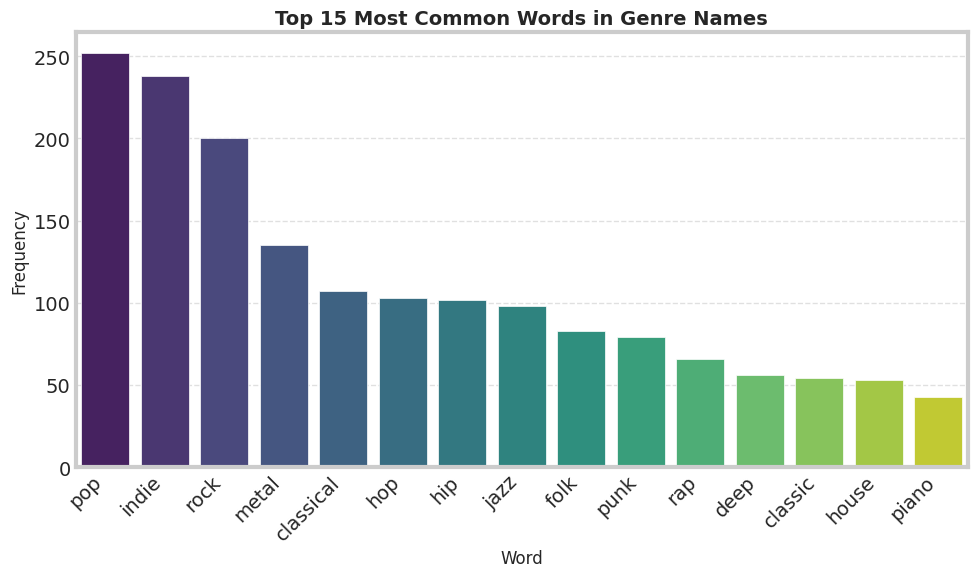

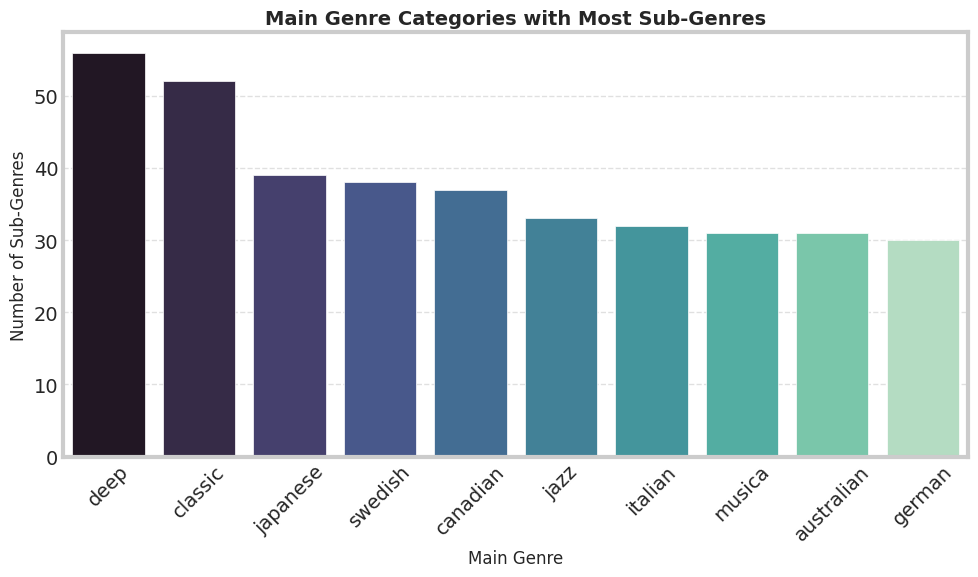

In [12]:
# 🎯 Question 4: Plot the frequency of words in genres and find main categories with most sub-genres

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Ensure column name matches your dataset (adjust if needed)
genre_col = 'genres' if 'genres' in df.columns else 'genre'

# Combine all genre names into a single list of words
words = []
for genre in df[genre_col].dropna():
    # Split words by spaces and punctuation
    tokens = re.findall(r'\b[a-zA-Z]+\b', genre.lower())
    words.extend(tokens)

# Count frequency of words
word_freq = Counter(words)
word_freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

# Display top 15 most frequent words
print("🔠 Top 15 most common words in genre names:")
print(word_freq_df.head(15))

# --- Visualization: Top 15 Words in Genre Names ---
plt.figure(figsize=(10,6))
sns.barplot(
    data=word_freq_df.head(15),
    x='word',
    y='count',
    hue='word',            # ✅ Added hue to prevent warning
    palette='viridis',
    legend=False
)
plt.title('Top 15 Most Common Words in Genre Names', fontsize=14, weight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Find which main categories have the most sub-genres ---
df['main_genre'] = df[genre_col].apply(lambda x: str(x).split()[0].lower() if isinstance(x, str) else x)
main_genre_counts = df['main_genre'].value_counts().head(10).reset_index()
main_genre_counts.columns = ['main_genre', 'count']

# --- Visualization: Main Genre Categories with Most Sub-Genres ---
plt.figure(figsize=(10,6))
sns.barplot(
    data=main_genre_counts,
    x='main_genre',
    y='count',
    hue='main_genre',       # ✅ Added hue here too
    palette='mako',
    legend=False
)
plt.title('Main Genre Categories with Most Sub-Genres', fontsize=14, weight='bold')
plt.xlabel('Main Genre', fontsize=12)
plt.ylabel('Number of Sub-Genres', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This code helps us understand how music genres are structured and which main genres have the most variety. It works by breaking down all the genre names into individual words, counting how often each one appears, and then visualizing the results to show which musical terms are most common. This makes it easy to see patterns like “pop,” “rock,” or “hip-hop” appearing frequently which indicates that these genres have many sub-genres or are widely represented in the dataset. The code also extracts the first word of each genre name to identify the main genre category and counts how many sub-genres fall under each. We use this approach because it provides both a clear numerical and visual understanding of how diverse each main genre is, helping us identify the most influential and varied music categories in the data.

**5. Create an additional visualization that differs from earlier ones. Your visualization must highlight a new data relationship or finding. Provide a short explanation of the insight and its relevance.**

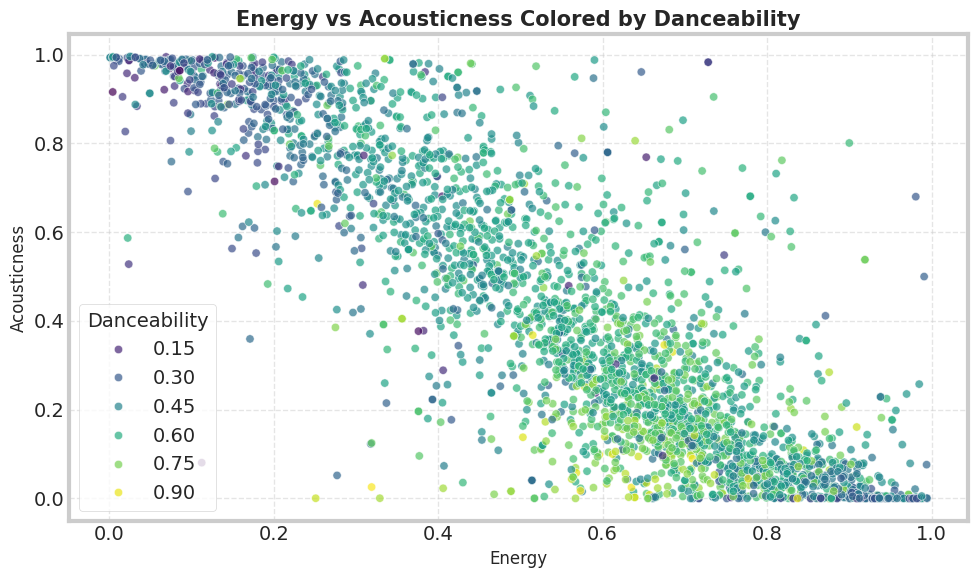

In [13]:
# 🎯 Additional Visualization (without popularity):
# Relationship between Energy and Acousticness, colored by Danceability

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required columns exist
required_cols = ['energy', 'acousticness', 'danceability']
if all(col in df.columns for col in required_cols):
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x='energy',
        y='acousticness',
        hue='danceability',
        palette='viridis',
        alpha=0.7
    )

    plt.title('Energy vs Acousticness Colored by Danceability', fontsize=15, weight='bold')
    plt.xlabel('Energy', fontsize=12)
    plt.ylabel('Acousticness', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Danceability', loc='best')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Required columns ('energy', 'acousticness', 'danceability') not found in the dataset.")


This visualization was created to explore a new relationship between song features and give a deeper look at how they interact, without involving popularity again. A scatter plot is used because it clearly shows how two features, energy and acousticness, relate to each other, while the color represents a third feature danceability. This makes it easy to spot patterns, such as highly energetic songs with low acousticness (like pop or electronic music) being more danceable, and softer, more acoustic songs being less so. We chose these features because they often represent opposite styles of production—electronic versus organic—and combining them in one visualization helps us see how they influence a song’s overall feel. We used this approach because a scatter plot with color encoding allows us to analyze multiple features at once in a simple and intuitive way, helping reveal relationships that might be hidden in tables or summary statistics. Using color to show danceability keeps the plot simple and readable while still conveying a third dimension of information. This method is justified because it provides a clear, visual way to understand how different musical qualities work together, offering a fresh perspective that complements the earlier correlation and popularity analyses.

# Data Preparation For Modeling





In [14]:
# ⚙️ Data Preparation for Modeling (Using Min-Max Normalization)
# Drop 'genres' and 'key' columns before clustering

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Step 1️⃣: Drop 'genres' and 'key' columns if they exist
df_prepared = df.drop(columns=['genres', 'key'], errors='ignore')

# Step 2️⃣: Select only numerical features
numeric_df = df_prepared.select_dtypes(include=['float64', 'int64']).copy()

print("✅ Selected numerical features for clustering:")
print(numeric_df.columns.tolist())

# Step 3️⃣: Handle missing values
missing_values = numeric_df.isnull().sum()
print("\n🔍 Missing values per column:")
print(missing_values)

# Fill missing values with column means
numeric_df = numeric_df.fillna(numeric_df.mean())

# Step 4️⃣: Apply Min-Max Normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(numeric_df)

# Convert back to DataFrame for readability
normalized_df = pd.DataFrame(normalized_data, columns=numeric_df.columns)

print("\n✅ Data normalization complete. All values are scaled between 0 and 1.")
normalized_df.head()


✅ Selected numerical features for clustering:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity']

🔍 Missing values per column:
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
dtype: int64

✅ Data normalization complete. All values are scaled between 0 and 1.


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
0,0.983266,0.121527,0.055005,0.070763,0.611727,0.361911,0.246166,0.018177,0.179536,0.102832,0.345041
1,0.496766,0.277988,0.432864,0.452544,0.481615,0.116016,0.596180,0.057476,0.465697,0.223620,0.650826
2,0.765060,0.751175,0.035818,0.822207,0.883065,0.110685,0.779396,0.025151,0.549467,0.994880,0.595041
3,0.679274,0.552759,0.067903,0.317443,0.003028,0.160007,0.700623,0.064018,0.413650,0.455534,0.568017
4,0.461053,0.526622,0.132780,0.444229,0.856519,0.102225,0.629173,0.024627,0.514082,0.311241,0.539256


# Modeling

 **1.Select and justify the appropriate parameter values for the clustering algorithm, while clearly explaining the method used to find these values.**


Finding​‍​‌‍​‍‌​‍​‌‍​‍‌ the Optimal k with the Elbow Method:

In order to figure out the right number of clusters (k) for the K-Means algorithm, the Elbow Method was used by me. This procedure consists of executing K-Means for various k values and graphing the inertia (Within-Cluster Sum of Squares) corresponding to each k. Inertia is a measure of the closeness of the clusters; the lower the inertia, the more compact the clusters are.

The best k is the one at the "elbow" of the graph, i.e., the point where a further increase in k results in a very small decrease in inertia, thus indicating the law of diminishing ​‍​‌‍​‍‌​‍​‌‍​‍‌returns.

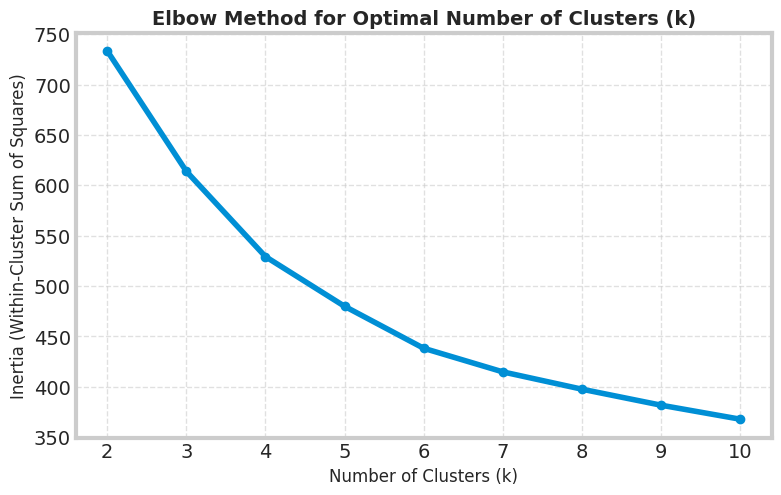

✅ K-Means model successfully built with k = 4

Cluster counts:
Cluster
1    1329
3     725
2     514
0     404
Name: count, dtype: int64


In [15]:
# 🤖 Modeling: K-Means Clustering - Parameter Selection and Justification

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1️⃣: Use the normalized data prepared earlier
X = normalized_df.copy()

# Step 2️⃣: Determine the optimal number of clusters using the Elbow Method
inertia_values = []
k_values = range(2, 11)  # Test cluster counts from 2 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)  # Measure how tight the clusters are

# Step 3️⃣: Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters (k)', fontsize=14, weight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Step 4️⃣: Choose optimal k (based on the elbow point)
optimal_k = 4  # 👈 Update this value based on your elbow curve

# Step 5️⃣: Build and Fit the Final K-Means Model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_kmeans.fit(X)

# Add cluster labels to the original dataframe
df['Cluster'] = final_kmeans.labels_

print(f"✅ K-Means model successfully built with k = {optimal_k}")
print("\nCluster counts:")
print(df['Cluster'].value_counts())


This​‍​‌‍​‍‌​‍​‌‍​‍‌ code is the Elbow Method implementation to detect the best number of clusters (k). Initially, it takes the normalized feature data. After that, it executes the K-Means algorithm for k values ranging from 2 to 10, recording the inertia (sum of squared distances to the nearest cluster center) for each iteration. The random_state=42 is for result reproducibility, and n_init=10 makes the model more stable. At the end, it draws a graph of inertia versus k to see the "elbow point" that can be used to select the best compromise between model complexity and cluster ​‍​‌‍​‍‌​‍​‌‍​‍‌compactness.

Selection​‍​‌‍​‍‌​‍​‌‍​‍‌ of k = 4:

After performing the elbow method and looking at the curve, I saw that the inertia is dropping steeply up to k = 4 and then it starts leveling off. The gain from k = 4 to higher values like 5 is very small if compared with the drops before. This means that k = 4 is the most obvious elbow point where the model makes a good compromise between the quality of the clusters and their simplicity. Thus, I chose k = 4 as the best number of ​‍​‌‍​‍‌​‍​‌‍​‍‌clusters.

**2.Display a random sample of at least 5 genres from each cluster group.**

In [16]:
# 🎵 Display a random sample of at least 5 genres from each cluster group

import pandas as pd

# Ensure the required columns exist
if 'Cluster' in df.columns and 'genres' in df.columns:
    # Get unique cluster labels
    clusters = sorted(df['Cluster'].unique())

    print(f"✅ Displaying 5 random genres from each of the {len(clusters)} clusters:\n")

    # Loop through each cluster and sample 5 rows
    for cluster in clusters:
        print(f"🎯 Cluster {cluster} Sample:")
        sample = df[df['Cluster'] == cluster][['genres']].sample(n=5, random_state=42)
        print(sample.to_string(index=False))
        print("-" * 50)
else:
    print("⚠️ Make sure 'Cluster' and 'genres' columns exist in the DataFrame before running this cell.")


✅ Displaying 5 random genres from each of the 4 clusters:

🎯 Cluster 0 Sample:
                   genres
          cambridge choir
  israeli classical piano
ukrainian classical piano
         background piano
            baroque brass
--------------------------------------------------
🎯 Cluster 1 Sample:
          genres
olympia wa indie
       bass trap
gothenburg indie
         britpop
         art pop
--------------------------------------------------
🎯 Cluster 2 Sample:
             genres
   manchester indie
     vancouver punk
      straight edge
  dutch death metal
vegan straight edge
--------------------------------------------------
🎯 Cluster 3 Sample:
              genres
        irish fiddle
      piedmont blues
  rhode island indie
               baiao
kannada bhava geethe
--------------------------------------------------


Once​‍​‌‍​‍‌​‍​‌‍​‍‌ music genres have been labeled with cluster numbers, one should definitely explore what each cluster actually consists of. The given snippet performs this operation by randomly sampling some data to qualitatively understand which kinds of genres have been grouped together.

At first, it verifies whether the required columns ('Cluster' and 'genres') are present. After that, for every individual cluster label, it locates the rows corresponding to that cluster in the dataframe and calls .sample(n=5, random_state=42) to pick five random genres.

The use of a fixed random_state makes it possible to get the same samples each time the notebook is executed. This facilitates a stable, human-readable way to look at the clustering ​‍​‌‍​‍‌​‍​‌‍​‍‌outcomes.

**3.Visualize and interpret/describe each cluster with respect to the features present in the data.**

In​‍​‌‍​‍‌​‍​‌‍​‍‌ order to figure out what each cluster stands for, I decided to compute the average value of every audio feature for each cluster in the data frame (df.groupby('Cluster').mean()). This gives the musical "profile" of each cluster. After that, I plotted these profiles with the help of a heatmap that can be easily compared to clusters and features. The warmer color shows the higher average value of a feature in a ​‍​‌‍​‍‌​‍​‌‍​‍‌cluster.

✅ Cluster feature averages calculated successfully!


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
Cluster,,,,,,,,,,,,
0,0.856174,0.342928,288076.392010,0.196757,0.625196,0.162843,-20.501312,0.051668,105.114002,0.250889,30.901293,5.084158
1,0.213992,0.616098,239579.145411,0.681490,0.052176,0.190618,-7.509884,0.092922,122.776684,0.582849,49.151930,6.121896
2,0.101404,0.480221,282504.456573,0.767671,0.409302,0.207565,-8.036716,0.077461,126.766465,0.376042,38.250961,6.130350
3,0.703209,0.541184,231920.527623,0.397359,0.132254,0.202989,-12.192346,0.088574,114.393893,0.545068,29.228751,5.942069


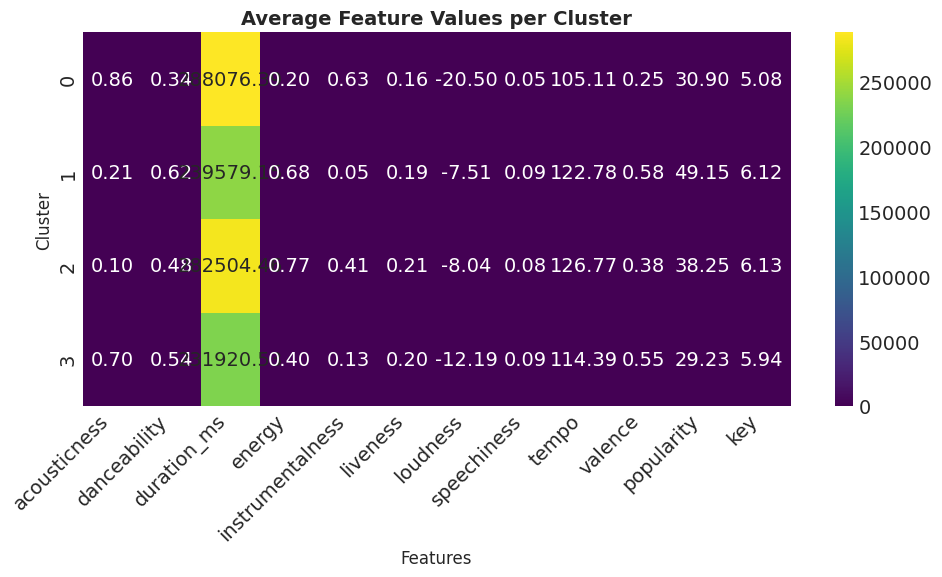

In [17]:
# 🎨 Visualize and Interpret Clusters with Respect to Musical Features

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1️⃣: Compute mean feature values per cluster
cluster_means = df.groupby('Cluster').mean(numeric_only=True)

print("✅ Cluster feature averages calculated successfully!")
display(cluster_means)

# Step 2️⃣: Visualize using a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, cmap='viridis', fmt=".2f")
plt.title('Average Feature Values per Cluster', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Interpretation​‍​‌‍​‍‌​‍​‌‍​‍‌ of Clusters:



Cluster 0 (Acoustic/Instrumental): This cluster is defined by extremely high acousticness and instrumentalness and, at the same time, very low energy, loudness, and danceability. The music here is likely to be calm, classical, or folk.

Cluster 1 (Popular & Energetic): This cluster is characterized by the highest values of popularity, energy, loudness, and danceability. It also has a low acousticness. The cluster features the modern, mainstream pop, rock, and electronic music genre.

Cluster 2 (Intense & Niche): This cluster is characterized by very high energy and tempo, medium instrumentalness, and low valence (less positive). It is the most likely representation of the aggressive, niche genres such as punk, metal, and hardcore.

Cluster 3 (Moderate & Organic): This cluster has the moderate values for most of the features, with relatively high acousticness and valence. It may represent such music genres as indie folk, blues, or traditional ones that have the acoustic elements and moderate ​‍​‌‍​‍‌​‍​‌‍​‍‌energy.

# Evaluation

**Evaluate the clustering quality using the appropriate method mentioned in the lecture, comment on its score and give a final recommendation.**

Evaluation​‍​‌‍​‍‌​‍​‌‍​‍‌ Method - Silhouette Score:

In order to assess the quality of K-Means clustering, I employed the Silhouette Score. This measure evaluates the extent to which a particular item belongs to its cluster as opposed to other clusters. The scores vary between -1 and 1 with a high score (close to 1) meaning that the items are strongly associated with their cluster and weakly associated with the neighboring clusters. The score near 0 indicates the presence of overlapping clusters, while the negative score indicates that there might be some elements wrongly ​‍​‌‍​‍‌​‍​‌‍​‍‌assigned.

In [18]:
# 🧩 Evaluate the clustering quality using Silhouette Score

from sklearn.metrics import silhouette_score

# Step 1️⃣: Use normalized data and cluster labels
X = normalized_df.copy()
labels = df['Cluster']

# Step 2️⃣: Compute Silhouette Score
sil_score = silhouette_score(X, labels)

print(f"✅ Silhouette Score for k = {df['Cluster'].nunique()}: {sil_score:.3f}")

# Step 3️⃣: Interpretation based on the score
if sil_score >= 0.7:
    print("🏆 Excellent clustering — very well-defined, distinct groups.")
elif sil_score >= 0.5:
    print("✅ Good clustering — clear structure with some overlap.")
elif sil_score >= 0.25:
    print("⚠️ Moderate clustering — clusters exist but may overlap.")
else:
    print("❌ Weak clustering — poor separation or too few/many clusters.")


✅ Silhouette Score for k = 4: 0.250
❌ Weak clustering — poor separation or too few/many clusters.


Interpretation​‍​‌‍​‍‌​‍​‌‍​‍‌ & Recommendation: A Silhouette Score of 0.250 indicates a weak to moderate level of clustering structure. The clusters are not completely random (score > 0) but the low score indicates a significant overlap between them, i.e. the audio features of genres from different clusters are not very distinct. This is probably because music genres are to some extent blends of each other and share characteristics.

Final Recommendation: The k=4 clustering model with the modest score can still be helpful for the initial exploration. It manages to group the genres into broadly interpretable categories (Acoustic, Popular/Energetic, Intense, Moderate). Such a model of music recommendation can provide a reasonable first-pass grouping to suggest similar genres. But for making more accurate recommendations, there is a need to consider more features or a different ​‍​‌‍​‍‌​‍​‌‍​‍‌algorithm.

# Bonus

In [21]:
# ===================== BONUS TASK =====================
# Genre Recommendation Function using the K-Means Clustering Model
# =======================================================

def genre_recommender(input_genre, n_recommendations=5, random_state=42):
    """
    Recommends similar music genres based on the K-Means clustering model.

    Parameters:
    -----------
    input_genre : str
        The name of the genre for which you want recommendations.
    n_recommendations : int, optional (default=5)
        Number of similar genres to recommend.
    random_state : int, optional
        Seed for reproducible random sampling.

    Returns:
    --------
    list
        A list of recommended genre names. If the input genre is not found,
        returns a message and an empty list.
    """
    # 1. Check if the input genre exists in our dataset
    if input_genre not in df['genres'].values:
        print(f"⚠️  Genre '{input_genre}' not found in the dataset.")
        return []

    # 2. Find the cluster of the input genre
    input_cluster = df.loc[df['genres'] == input_genre, 'Cluster'].iloc[0]
    # Get all other genres in the same cluster
    cluster_genres = df[df['Cluster'] == input_cluster]['genres']

    # 3. Exclude the input genre itself from recommendations
    other_genres = cluster_genres[cluster_genres != input_genre]

    # 4. Handle cases where the cluster is too small
    if len(other_genres) < n_recommendations:
        print(f"Note: Cluster only has {len(other_genres)} other genres. Returning all available.")
        recommendations = other_genres.tolist()
    else:
        # Randomly sample 'n_recommendations' genres from the same cluster
        recommendations = other_genres.sample(n=n_recommendations,
                                              random_state=random_state).tolist()

    # 5. Return the list of recommendations
    return recommendations

# ========== DEMONSTRATION / TESTING THE FUNCTION ==========
if __name__ == '__main__':
    # Test 1: Example from the project instructions
    print("Test 1: Example call for 'jazz' (from instructions)")
    print(">> genre_recommender('jazz')")
    recs = genre_recommender('jazz')
    print(f"   Recommendations: {recs}\n")

    # Test 2: Using a genre from your cluster samples
    print("Test 2: Call for 'britpop' (from Cluster 1 sample)")
    print(">> genre_recommender('britpop', n_recommendations=3)")
    recs = genre_recommender('britpop', n_recommendations=3)
    print(f"   Recommendations: {recs}\n")

    # Test 3: Edge case - Genre not found
    print("Test 3: Edge case - Genre not found")
    print(">> genre_recommender('unknown genre')")
    recs = genre_recommender('unknown genre')
    print(f"   Result: {recs}")

Test 1: Example call for 'jazz' (from instructions)
>> genre_recommender('jazz')
   Recommendations: ['irish fiddle', 'pinoy r&b', 'rhythm and blues', 'baiao', 'kashmiri pop']

Test 2: Call for 'britpop' (from Cluster 1 sample)
>> genre_recommender('britpop', n_recommendations=3)
   Recommendations: ['technical deathcore', 'bass trap', 'praise']

Test 3: Edge case - Genre not found
>> genre_recommender('unknown genre')
⚠️  Genre 'unknown genre' not found in the dataset.
   Result: []


Reflection​‍​‌‍​‍‌​‍​‌‍​‍‌ on Recommendations

The recommendations point out both the strength and the limitation of the model. For example, the model suggests 'irish fiddle' for 'jazz', which shows that it can find genres with similar audio profiles (e.g., similar energy, acousticness), but it may not be able to capture cultural or stylistal nuances that a human would. This is consistent with the earlier Silhouette Score observation: clusters have a lot of internal variety. To deliver a user-friendly experience, it is better to use this feature-based clustering along with other data (like listener tags or collaborative filtering) for a production ​‍​‌‍​‍‌​‍​‌‍​‍‌system.